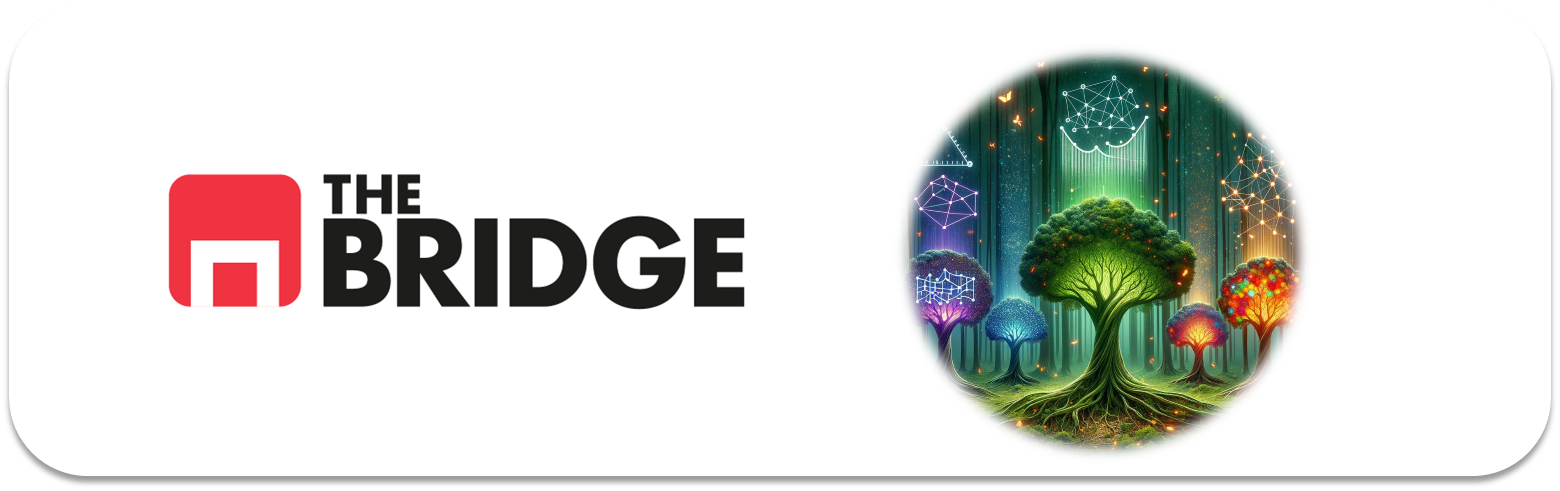

## PRACTICA OBLIGATORIA: **Arboles de Decisión y Ajuste de Hiperparámetros**

* La práctica obligatoria de esta unidad consiste en encontrar el mejor modelo para resolver un problema de predicción de si los destinatarios de una campaña de marketing adquirirán un producto concreto. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Descripción

En el directorio data encontrarás un dataset que contiene datos relacionados con campañas de marketing directo de una institución bancaria portuguesa (es el dataset "Bank Marketing" de la UCI Machine Learning Repository). Los datos se recopilaron de campañas de marketing telefónico, donde el objetivo principal era predecir si el cliente se suscribiría a un depósito a plazo.

La práctica consiste en completar el proceso de creación de un modelo basado en árboles de decisión que permita predecir si un cliente (dadas unas características similares a las del dataset) "comprará" el depósito a plazo. Sigue los pasos necesarios de un proceso de ML para crear el modelo, optimizar sus hiperparámetros, comparar los resultados de esa optimización con una regresión logística (sin optimizar, con sus hiperparámetros por defecto) y finalmente evaluarlo contra test y hacer una pequeña valoración del resultado obtenido.

Tendrás que hacer la limpieza, split, minieda, selección, tratamiento, primeros entrenamientos, optimización, comparación y evaluación según tu mejor criterio. Eso sí, es obligatorio:
- Identificar el target y analizar su distribución
- Realizar una optimización de hiperparámetros, escogiendo un grid medianemante razonado
- Comparar con el modelo baseline
- Evaluar contra test

AYUDA: La dirección del banco nos proporciona estas notas (en inglés):

 
   **bank client data:**  
   1 - age (numeric)  
   2 - job : type of job (categorical: "admin.","unknown","unemployed","management","housemaid","entrepreneur","student",
                                       "blue-collar","self-employed","retired","technician","services")   
   3 - marital : marital status (categorical: "married","divorced","single"; note: "divorced" means divorced or widowed)  
   4 - education (categorical: "unknown","secondary","primary","tertiary")  
   5 - default: has credit in default? (binary: "yes","no")  
   6 - balance: average yearly balance, in euros (numeric)   
   7 - housing: has housing loan? (binary: "yes","no")  
   8 - loan: has personal loan? (binary: "yes","no")   

   **related with the last contact of the current campaign:**  
   9 - contact: contact communication type (categorical: "unknown","telephone","cellular")   
  10 - day: last contact day of the month (numeric)  
  11 - month: last contact month of year (categorical: "jan", "feb", "mar", ..., "nov", "dec")  
  12 - duration: last contact duration, in seconds (numeric)    

   **other attributes:**  
  13 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)  
  14 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric, -1 means client was not previously contacted)  
  15 - previous: number of contacts performed before this campaign and for this client (numeric)  
  16 - poutcome: outcome of the previous marketing campaign (categorical: "unknown","other","failure","success")

  

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, ConfusionMatrixDisplay, make_scorer, f1_score,
)


def buscar_fichero(nombre, directorio_inicio="."):
    """Busca `nombre` en el directorio actual y en todas sus subcarpetas,
    para no depender de rutas absolutas fijas en el equipo de cada uno."""
    candidatas = [os.path.join(directorio_inicio, nombre)]
    for ruta in candidatas:
        if os.path.exists(ruta):
            return ruta
    for raiz, _, ficheros in os.walk(directorio_inicio):
        if nombre in ficheros:
            return os.path.join(raiz, nombre)
    return None


ruta_bootcamp = buscar_fichero("bootcampviztools.py")
if ruta_bootcamp is None:
    raise FileNotFoundError("No se ha encontrado 'bootcampviztools.py' junto al notebook.")
sys.path.append(os.path.dirname(os.path.abspath(ruta_bootcamp)))
import bootcampviztools as bt

pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")
np.random.seed(42)


### EMPEZAMOS: primer vistazo al dataset

In [2]:
ruta_csv = buscar_fichero("bank-full.csv")
if ruta_csv is None:
    raise FileNotFoundError(
        "No se ha encontrado 'bank-full.csv'. Debe estar en alguna subcarpeta "
        "(p.ej. 'data/bank-full.csv') dentro del directorio de este notebook."
    )

print("Cargando dataset desde:", ruta_csv)
df = pd.read_csv(ruta_csv, sep=";")
target = "y"
df.shape


Cargando dataset desde: .\data\bank-full.csv


(45211, 17)

In [3]:
df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


### Valores "unknown"

El dataset no tiene NaNs técnicos, pero varias variables categóricas codifican los
missings como la categoría `"unknown"`. Los cuantificamos para decidir cómo tratarlos.

In [6]:
resumen_unknown = pd.DataFrame({
    "columna": df.columns,
    "n_unknown": [int((df[c] == "unknown").sum()) if df[c].dtype == "object" else 0 for c in df.columns],
})
resumen_unknown["pct_unknown"] = (resumen_unknown["n_unknown"] / len(df) * 100).round(2)
resumen_unknown = resumen_unknown[resumen_unknown["n_unknown"] > 0].sort_values("pct_unknown", ascending=False)
resumen_unknown


,columna,n_unknown,pct_unknown
15,poutcome,36959,81.75
8,contact,13020,28.80
3,education,1857,4.11
1,job,288,0.64


`poutcome` tiene un 81% de "unknown" (clientes que nunca habían sido contactados antes en
campañas previas) y `contact` un 28%. `job` y `education` tienen un porcentaje mucho más
bajo. En todos los casos son variables **categóricas**, así que optamos por tratar
`"unknown"` como una categoría más (aporta información real: "no lo sabemos" o "no aplica"),
en vez de imputarla o eliminar filas.

### Distribución del target

`y` indica si el cliente contrató o no el depósito a plazo.

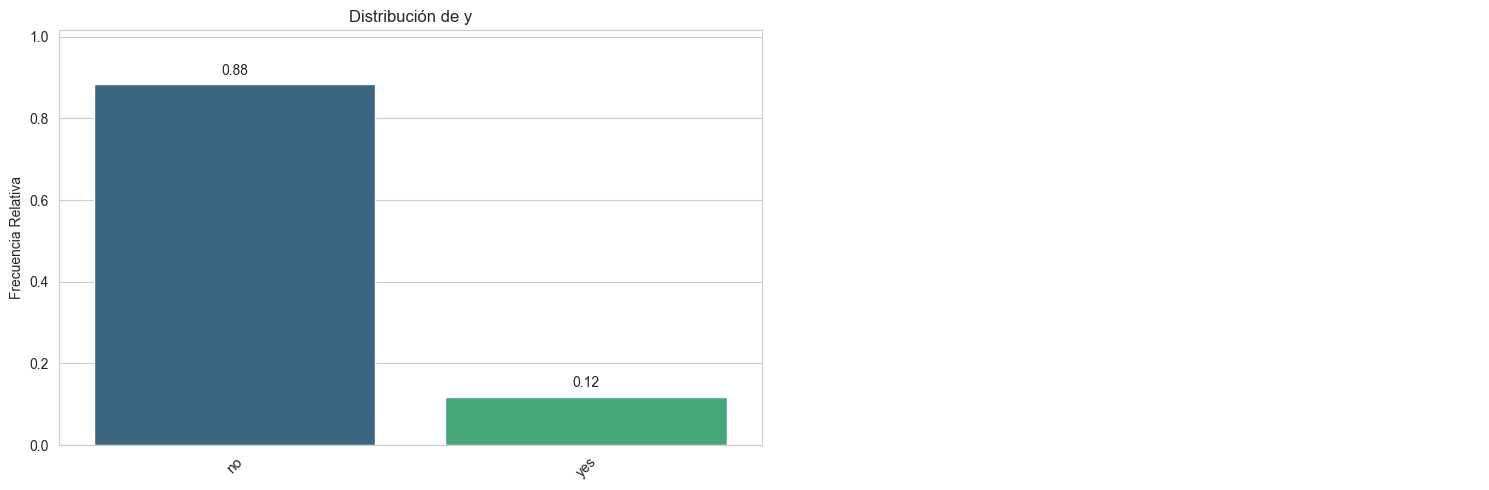

In [7]:
bt.pinta_distribucion_categoricas(df, [target], relativa=True, mostrar_valores=True)


In [8]:
df[target].value_counts(normalize=True).round(3)


y
no     0.883
yes    0.117
Name: proportion, dtype: float64

El target está **claramente desbalanceado**: en torno al 88% de los clientes no contrata
el depósito frente a un 12% que sí. Esto tiene varias implicaciones:

- La **accuracy** por sí sola será poco informativa (un modelo que siempre prediga "no"
  acertaría ~88% de las veces).
- Conviene usar métricas que tengan en cuenta ambas clases, como **f1**, **recall de la
  clase positiva** o **balanced accuracy**, y también manejar el desbalanceo con
  `class_weight="balanced"` como hiperparámetro a probar en la búsqueda.

### Train / test split

Usamos `stratify` sobre el target para que train y test mantengan la misma proporción de
clases, dado lo desbalanceado que está.

In [9]:
train_set, test_set = train_test_split(
    df, test_size=0.25, random_state=42, stratify=df[target]
)

print("Train:", train_set.shape, " Test:", test_set.shape)
print("\nDistribución train:")
print(train_set[target].value_counts(normalize=True).round(3))
print("\nDistribución test:")
print(test_set[target].value_counts(normalize=True).round(3))


Train: (33908, 17)  Test: (11303, 17)

Distribución train:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64

Distribución test:
y
no     0.883
yes    0.117
Name: proportion, dtype: float64


### Mini-EDA

In [10]:
features_cat = train_set.select_dtypes(include="object").columns.to_list()
features_cat.remove(target)
features_num = [c for c in train_set.columns if c not in features_cat + [target]]

print("Categóricas:", features_cat)
print("Numéricas  :", features_num)


Categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numéricas  : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


**Categóricas:** en vez de decidir a ojo qué variable categórica aporta poco, usamos un
**test de chi-cuadrado de independencia** entre cada categórica y el target: si el p-valor
es alto, no hay evidencia de asociación y es candidata a descartar.

In [11]:
resultados_chi2 = []
for col in features_cat:
    tabla = pd.crosstab(train_set[col], train_set[target])
    chi2, p, dof, _ = chi2_contingency(tabla)
    resultados_chi2.append({"feature": col, "chi2": round(chi2, 1), "p_valor": p})

chi2_df = pd.DataFrame(resultados_chi2).sort_values("p_valor")
chi2_df


,feature,chi2,p_valor
7,month,2210.6,0.000000e+00
8,poutcome,3177.8,0.000000e+00
6,contact,774.6,6.258362e-169
4,housing,643.2,6.612172e-142
0,job,653.0,6.367079e-133
1,marital,158.6,3.555116e-35
2,education,163.1,3.843914e-35
5,loan,148.4,3.791218e-34
3,default,17.8,2.517057e-05


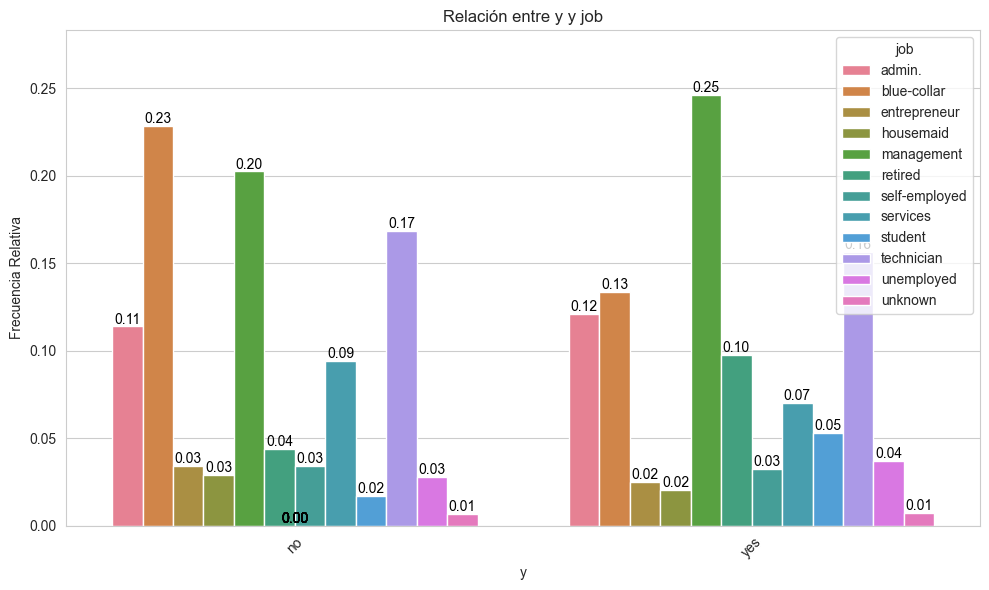

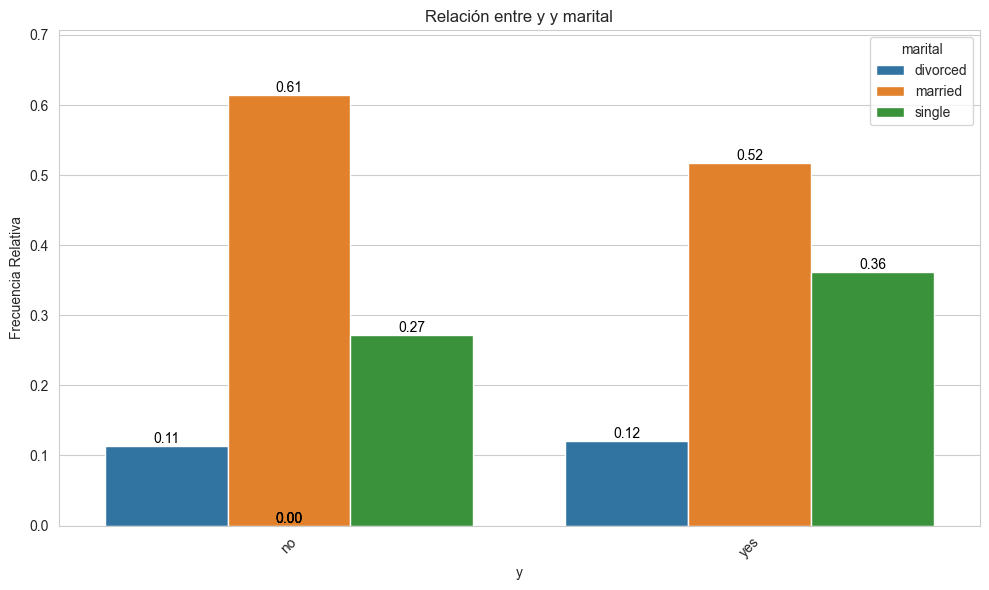

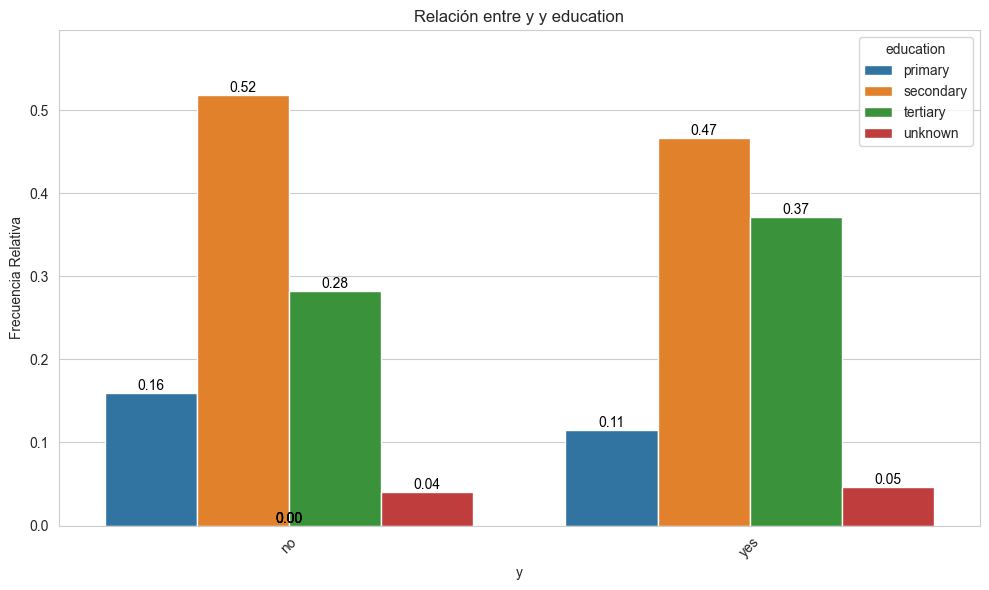

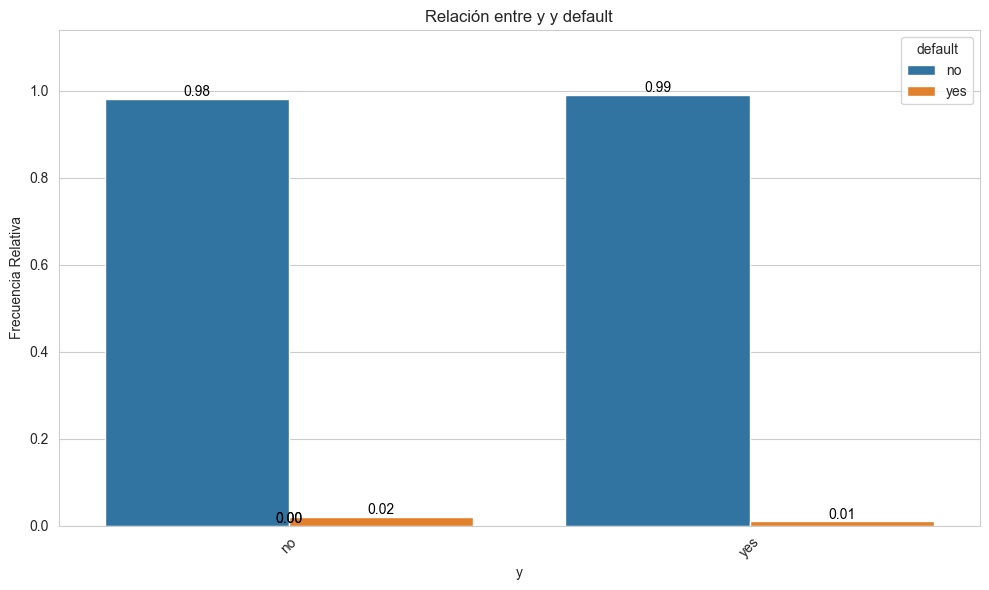

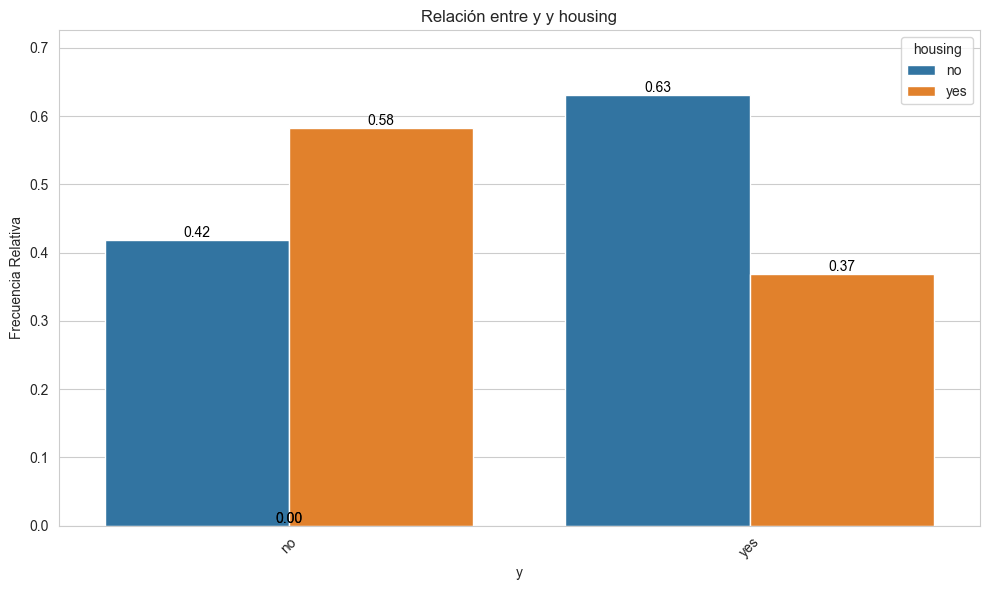

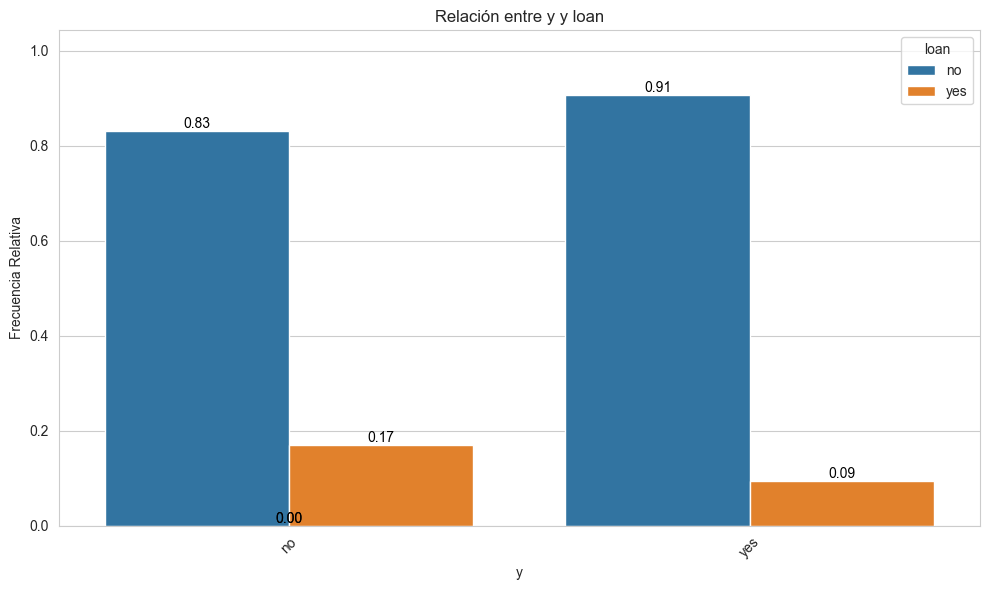

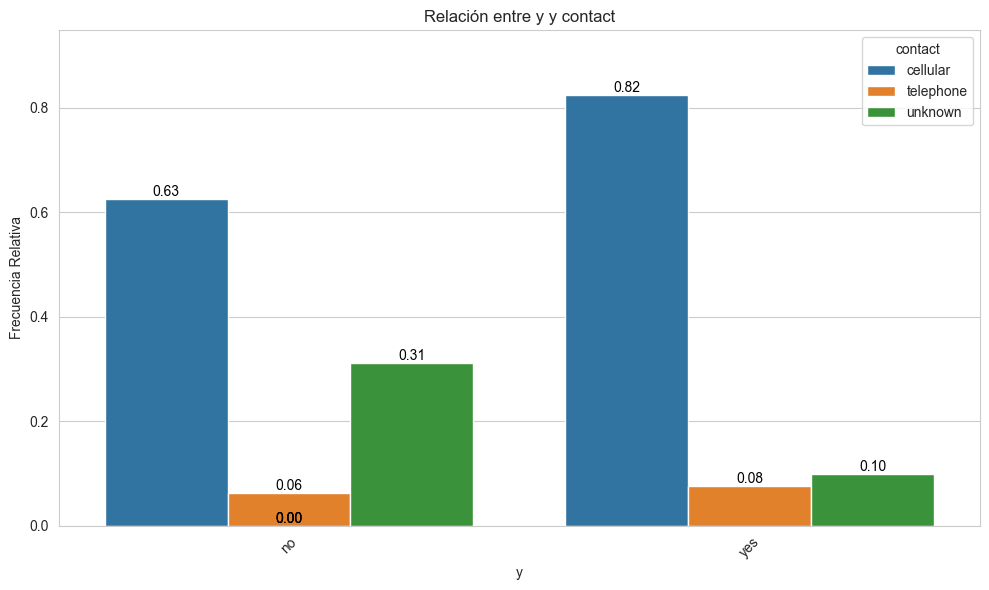

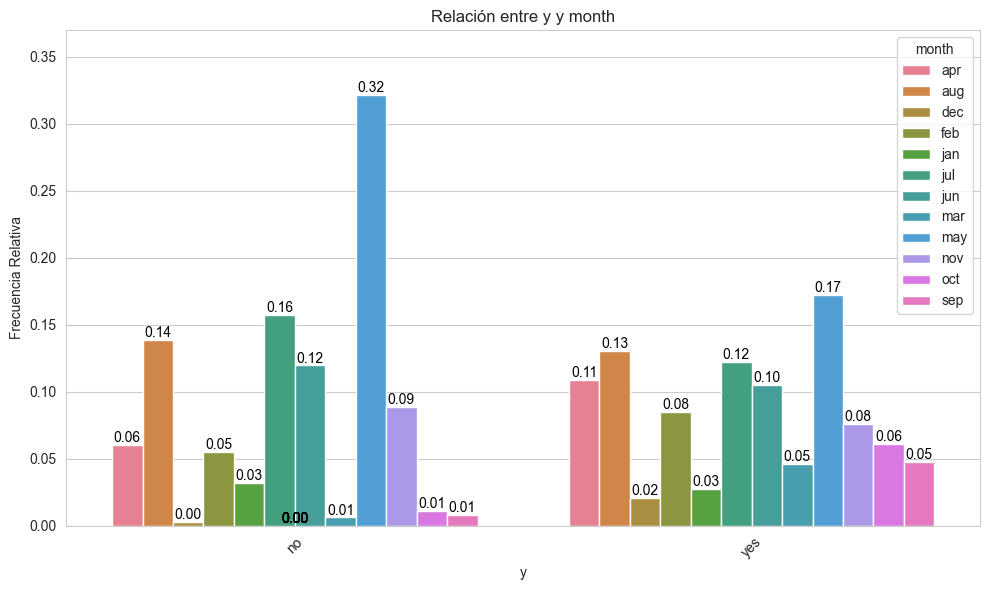

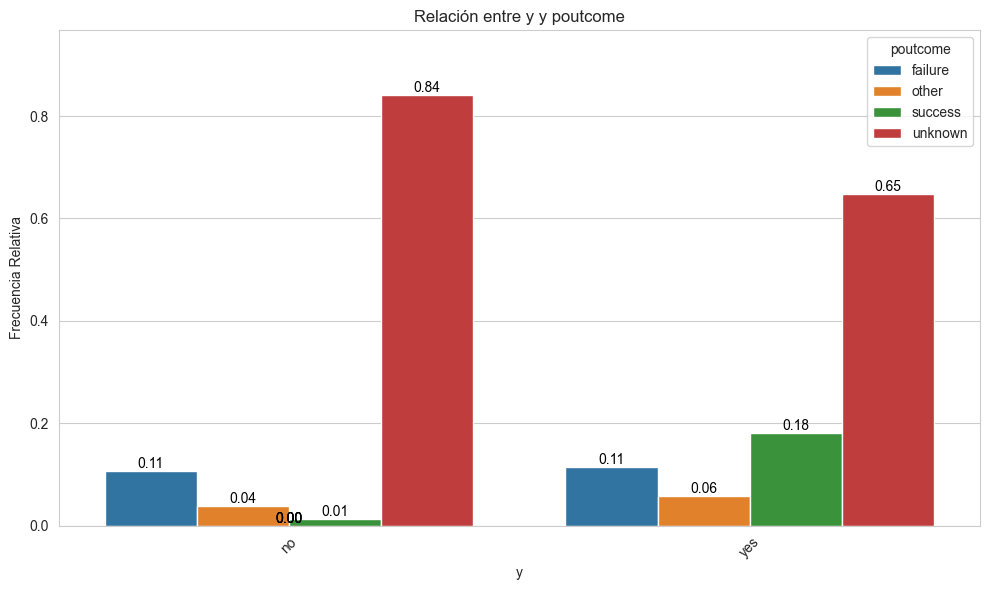

In [12]:
for col in features_cat:
    bt.plot_categorical_relationship(train_set, target, col, relative_freq=True, show_values=True)


El test de chi-cuadrado confirma numéricamente lo que ya se intuye en los gráficos:
`default` tiene, con diferencia, el p-valor más alto (no hay evidencia de asociación
significativa con el target), así que la descartamos. El resto de categóricas sí muestran
asociación clara y las mantenemos para ver qué importancia les da el propio árbol.

In [13]:
features_cat.remove("default")

# La quitamos también del propio dataframe: al no formar parte de features_cat
# nunca pasaría por el get_dummies, y se quedaría como texto sin codificar
# colándose luego en el listado de columnas del modelo.
train_set = train_set.drop(columns=["default"])
test_set = test_set.drop(columns=["default"])

features_cat


['job',
 'marital',
 'education',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome']

### Numéricas

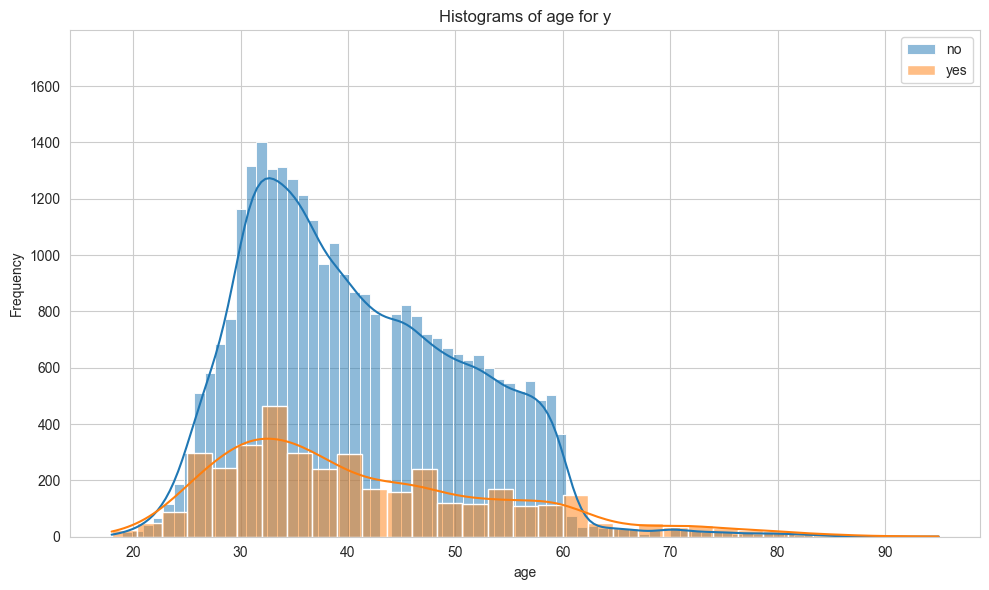

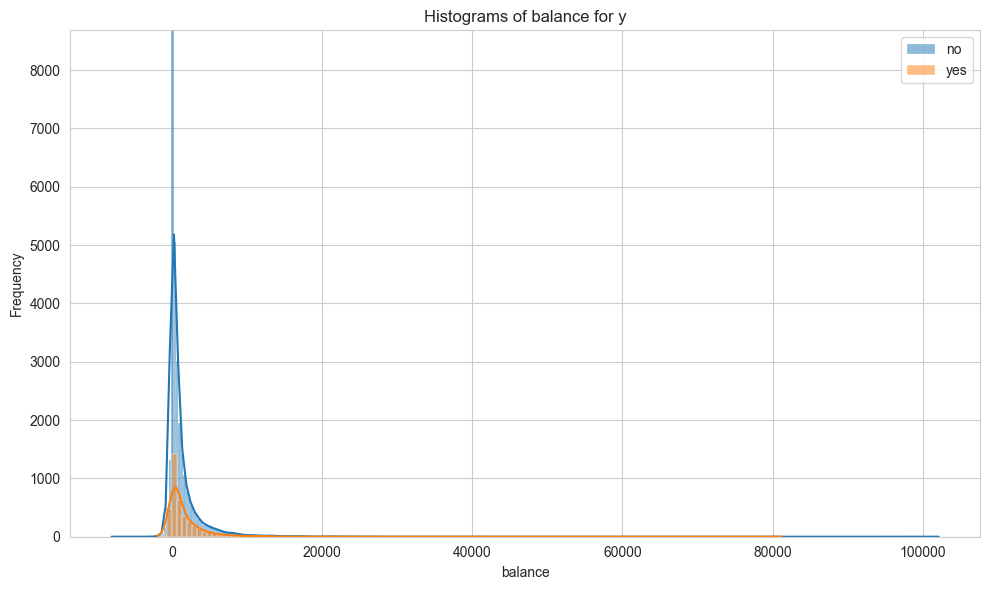

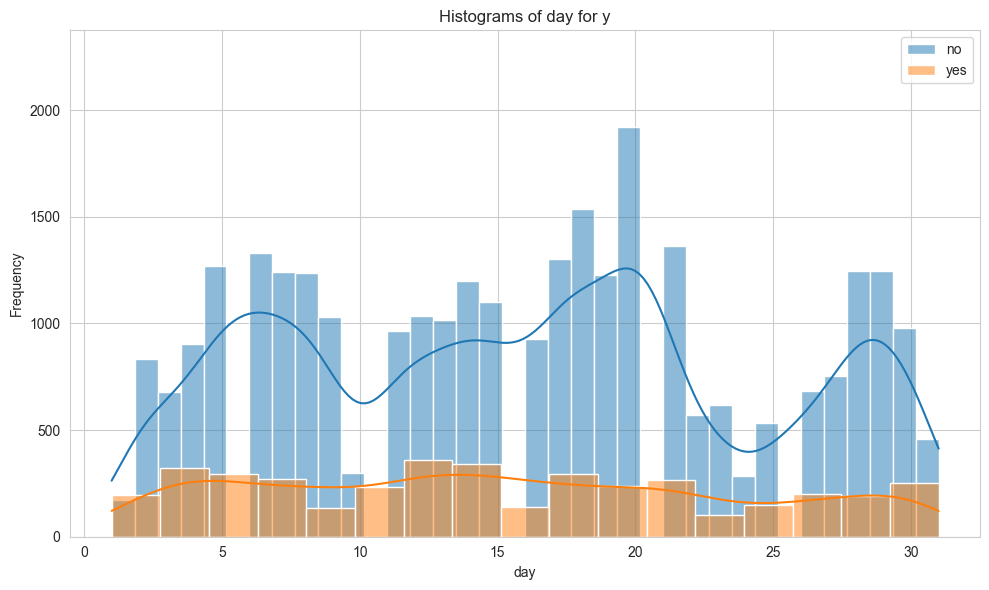

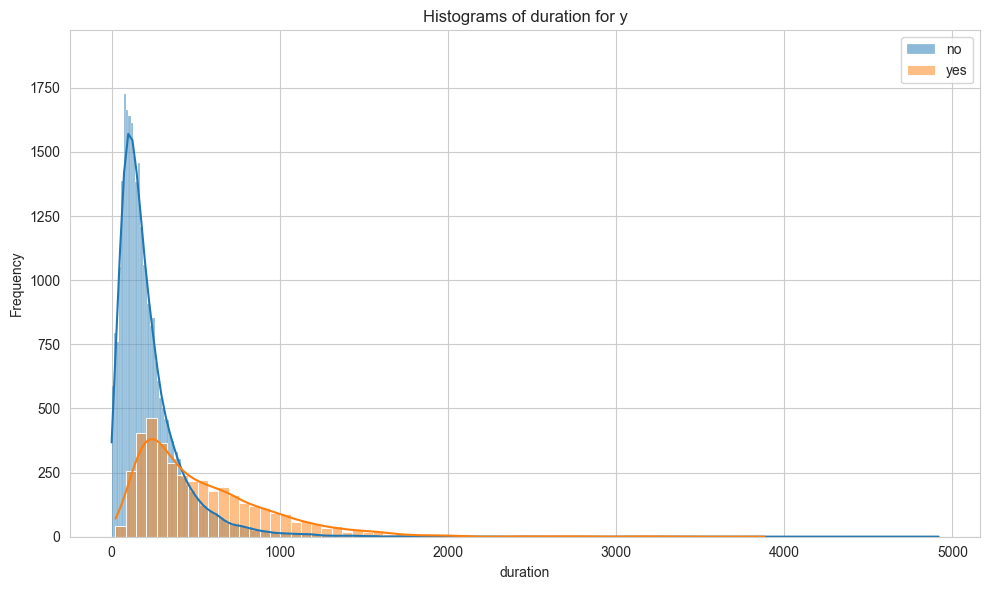

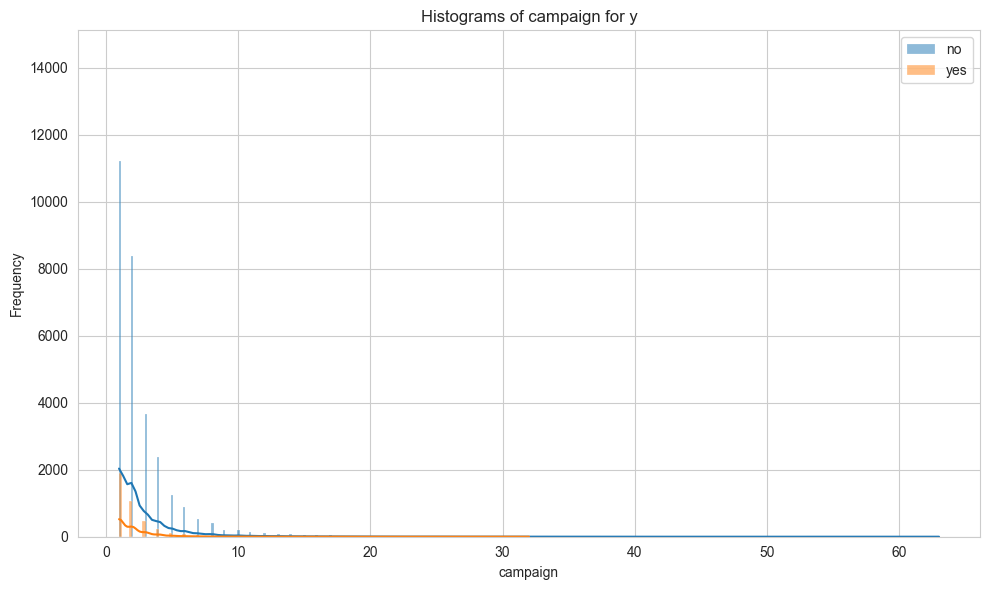

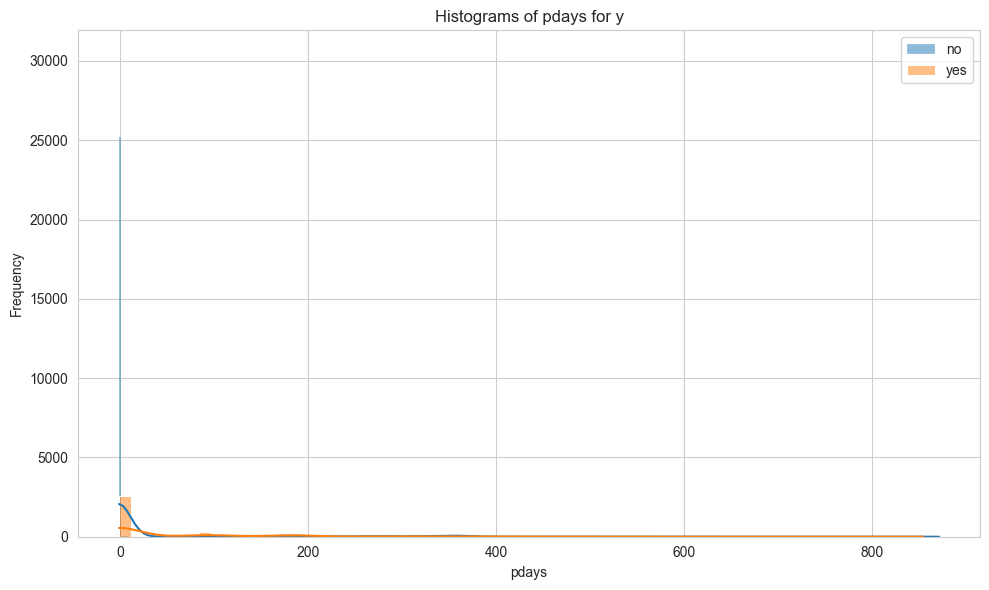

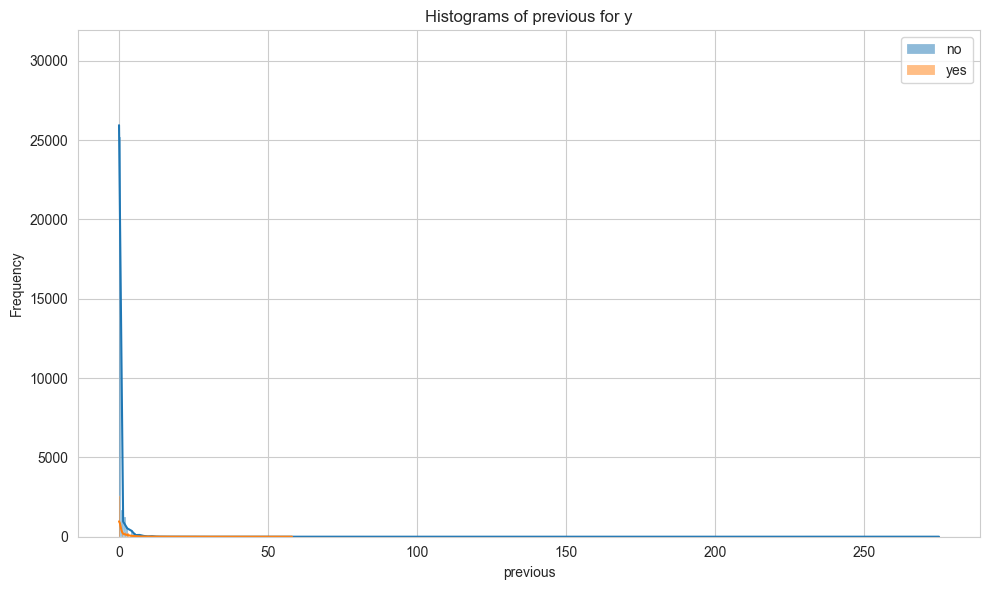

In [14]:
for col in features_num:
    bt.plot_grouped_histograms(train_set, cat_col=target, num_col=col, group_size=2)


In [15]:
train_set[features_num].describe().T


,count,mean,std,min,25%,50%,75%,max
age,33908.0,40.907957,10.620338,18.0,33.0,39.0,48.0,95.0
balance,33908.0,1362.457709,3052.176471,-8019.0,74.0,451.0,1432.0,102127.0
day,33908.0,15.825233,8.339007,1.0,8.0,16.0,21.0,31.0
duration,33908.0,258.473015,258.936344,0.0,103.0,180.0,318.0,4918.0
campaign,33908.0,2.759555,3.094060,1.0,1.0,2.0,3.0,63.0
pdays,33908.0,40.024979,100.018015,-1.0,-1.0,-1.0,-1.0,871.0
previous,33908.0,0.582635,2.445884,0.0,0.0,0.0,0.0,275.0


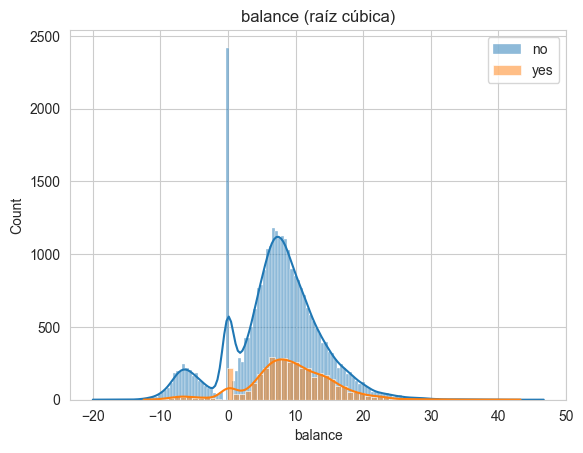

In [16]:
col = "balance"
fig, ax = plt.subplots()
sns.histplot(np.cbrt(train_set.loc[train_set[target] == "no", col]), kde=True, label="no", ax=ax)
sns.histplot(np.cbrt(train_set.loc[train_set[target] == "yes", col]), kde=True, label="yes", ax=ax)
ax.set_title("balance (raíz cúbica)")
ax.legend()
plt.show()


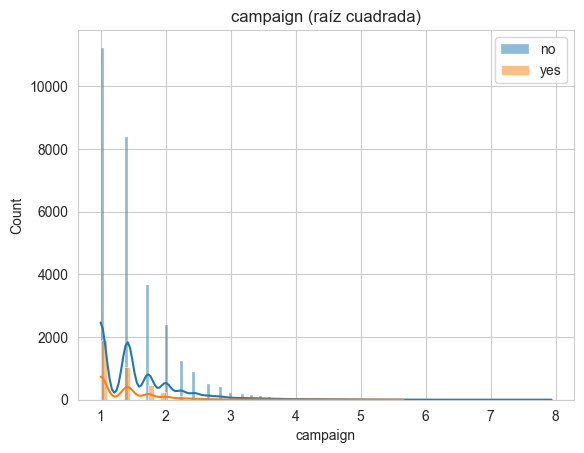

In [17]:
col = "campaign"
fig, ax = plt.subplots()
sns.histplot(np.sqrt(train_set.loc[train_set[target] == "no", col]), kde=True, label="no", ax=ax)
sns.histplot(np.sqrt(train_set.loc[train_set[target] == "yes", col]), kde=True, label="yes", ax=ax)
ax.set_title("campaign (raíz cuadrada)")
ax.legend()
plt.show()


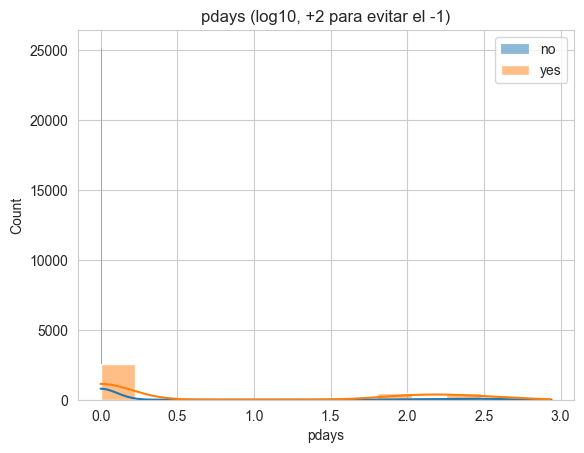

In [18]:
col = "pdays"
fig, ax = plt.subplots()
sns.histplot(np.log10(train_set.loc[train_set[target] == "no", col] + 2), kde=True, label="no", ax=ax)
sns.histplot(np.log10(train_set.loc[train_set[target] == "yes", col] + 2), kde=True, label="yes", ax=ax)
ax.set_title("pdays (log10, +2 para evitar el -1)")
ax.legend()
plt.show()


`balance`, `campaign`, `pdays` y `previous` están muy sesgadas (con outliers marcados), y en
todas ellas la clase "yes" parece desplazada respecto a "no" tras aplicar la transformación,
así que las mantenemos como candidatas útiles y las transformaremos antes de usarlas en el
modelo lineal.

### Tratamiento de variables

**Categóricas**: `housing` y `loan` son binarias -> las pasamos a booleano/entero. `month`
es ordinal (orden temporal con sentido) -> mapeo numérico. El resto, one-hot encoding.

In [19]:
train_set["housing"] = (train_set["housing"] == "yes").astype(int)
train_set["loan"] = (train_set["loan"] == "yes").astype(int)
test_set["housing"] = (test_set["housing"] == "yes").astype(int)
test_set["loan"] = (test_set["loan"] == "yes").astype(int)

features_cat.remove("housing")
features_cat.remove("loan")


In [20]:
orden_meses = {m: i + 1 for i, m in enumerate(
    ["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]
)}
train_set["month"] = train_set["month"].map(orden_meses)
test_set["month"] = test_set["month"].map(orden_meses)
features_cat.remove("month")

features_cat


['job', 'marital', 'education', 'contact', 'poutcome']

In [21]:
train_set = pd.get_dummies(train_set, columns=features_cat, dtype=int)
test_set = pd.get_dummies(test_set, columns=features_cat, dtype=int)

# Alineamos columnas por si alguna categoría no aparece en uno de los dos splits
todas_las_columnas = sorted(set(train_set.columns) | set(test_set.columns))
train_set = train_set.reindex(columns=todas_las_columnas, fill_value=0)
test_set = test_set.reindex(columns=todas_las_columnas, fill_value=0)

print("Train:", train_set.shape, " Test:", test_set.shape)


Train: (33908, 37)  Test: (11303, 37)


**Numérica `pdays`**: el valor -1 no es "menos que 0 días", es un código especial que
significa "nunca contactado antes". Lo separamos en una variable binaria propia antes de
transformar el resto de la escala.

In [22]:
train_set["fue_contactado_antes"] = (train_set["pdays"] != -1).astype(int)
test_set["fue_contactado_antes"] = (test_set["pdays"] != -1).astype(int)

train_set["fue_contactado_antes"].value_counts(normalize=True).round(3)


fue_contactado_antes
0    0.818
1    0.182
Name: proportion, dtype: float64

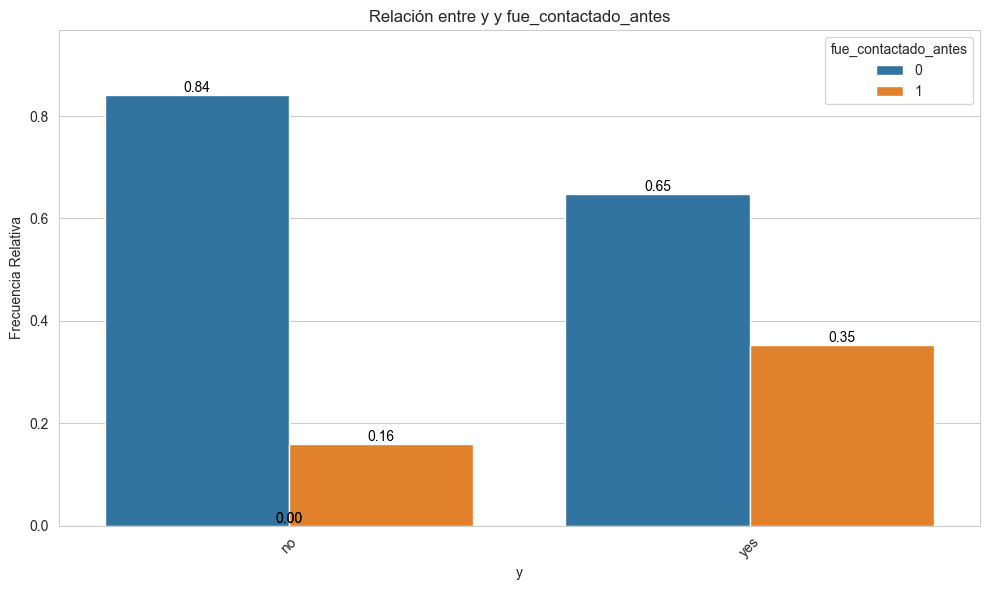

In [23]:
bt.plot_categorical_relationship(train_set, target, "fue_contactado_antes", relative_freq=True, show_values=True)


In [24]:
features_cat_encoded = [c for c in train_set.columns if c not in features_num + [target, "fue_contactado_antes"]]
features_cat_encoded = [c for c in features_cat_encoded]
features_cat_final = features_cat_encoded + ["fue_contactado_antes"]
len(features_cat_final), features_cat_final[:10]


(30,
 ['contact_cellular',
  'contact_telephone',
  'contact_unknown',
  'education_primary',
  'education_secondary',
  'education_tertiary',
  'education_unknown',
  'housing',
  'job_admin.',
  'job_blue-collar'])

### Transformación y escalado (solo para el modelo lineal)

Los árboles de decisión no necesitan escalado ni son sensibles a transformaciones
monótonas, así que mantenemos una versión "cruda" (`train_set` / `test_set`) para el árbol,
y una versión transformada+escalada (`*_scaled`) solo para la regresión logística.

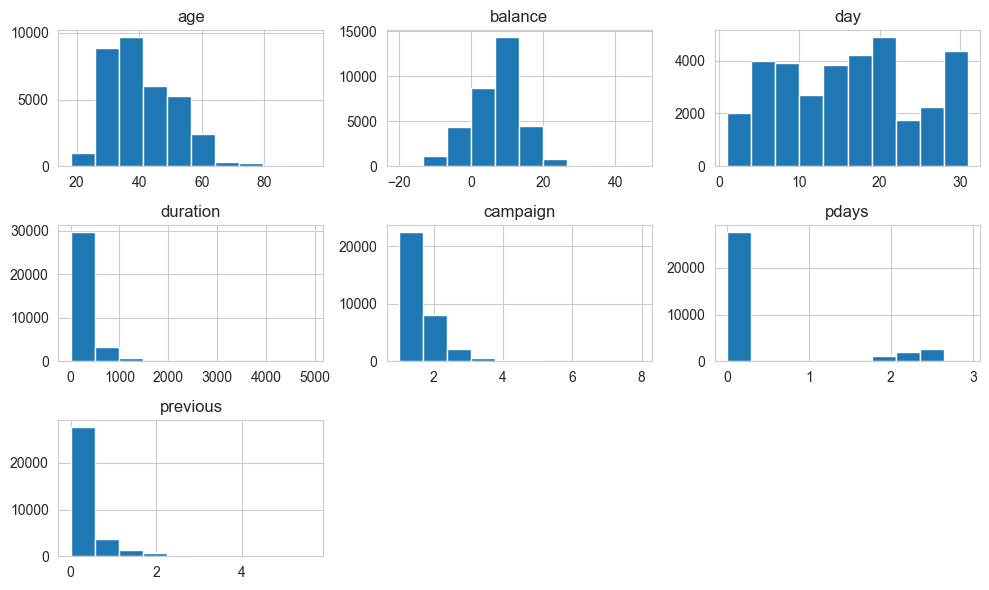

In [25]:
train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

# balance puede ser negativo -> raíz cúbica (admite negativos)
train_set_scaled["balance"] = np.cbrt(train_set_scaled["balance"])
test_set_scaled["balance"] = np.cbrt(test_set_scaled["balance"])

# campaign >= 1 siempre -> raíz cuadrada para suavizar la cola
train_set_scaled["campaign"] = np.sqrt(train_set_scaled["campaign"])
test_set_scaled["campaign"] = np.sqrt(test_set_scaled["campaign"])

# pdays incluye el -1 especial -> log10(pdays + 2) para que -1 -> log10(1) = 0
train_set_scaled["pdays"] = np.log10(train_set_scaled["pdays"] + 2)
test_set_scaled["pdays"] = np.log10(test_set_scaled["pdays"] + 2)

# previous >= 0 -> log1p
train_set_scaled["previous"] = np.log1p(train_set_scaled["previous"])
test_set_scaled["previous"] = np.log1p(test_set_scaled["previous"])

train_set_scaled[features_num].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()


In [26]:
# RobustScaler: usa mediana e IQR, más adecuado que StandardScaler cuando aún
# quedan outliers residuales tras las transformaciones anteriores.
scaler = RobustScaler()
train_set_scaled[features_num] = scaler.fit_transform(train_set_scaled[features_num])
test_set_scaled[features_num] = scaler.transform(test_set_scaled[features_num])

train_set_scaled[features_num].describe().T[["min", "50%", "max"]]


,min,50%,max
age,-1.400000,0.0,3.733333
balance,-3.914042,0.0,5.524262
day,-1.153846,0.0,1.153846
duration,-0.837209,0.0,22.037209
campaign,-0.565826,0.0,8.910639
pdays,0.000000,0.0,2.941014
previous,0.000000,0.0,5.620401


### Construcción final de X, y

In [27]:
features_finales = features_cat_final + features_num

X_train = train_set[features_finales].copy()
X_train_scaled = train_set_scaled[features_finales].copy()
y_train = train_set[target]

X_test = test_set[features_finales].copy()
X_test_scaled = test_set_scaled[features_finales].copy()
y_test = test_set[target]

X_train.shape, X_test.shape


((33908, 37), (11303, 37))

### Modelo baseline: regresión logística (sin optimizar)

Usamos `class_weight="balanced"` porque, dado el desbalance del target, sin él el modelo
tendería a predecir casi siempre "no".

In [28]:
lr_clf = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_clf.fit(X_train_scaled, y_train)

print("--- Regresión logística (train) ---")
print(classification_report(y_train, lr_clf.predict(X_train_scaled)))


--- Regresión logística (train) ---
              precision    recall  f1-score   support

          no       0.97      0.84      0.90     29941
         yes       0.40      0.81      0.53      3967

    accuracy                           0.83     33908
   macro avg       0.68      0.82      0.71     33908
weighted avg       0.90      0.83      0.86     33908



In [29]:
print("--- Regresión logística (test) ---")
print(classification_report(y_test, lr_clf.predict(X_test_scaled)))


--- Regresión logística (test) ---
              precision    recall  f1-score   support

          no       0.97      0.83      0.90      9981
         yes       0.39      0.79      0.52      1322

    accuracy                           0.83     11303
   macro avg       0.68      0.81      0.71     11303
weighted avg       0.90      0.83      0.85     11303



Para comparar de forma justa con el árbol (que se va a evaluar con validación cruzada
durante la búsqueda de hiperparámetros), evaluamos también la regresión logística con CV
sobre train, usando **f1** de la clase positiva ("yes") como métrica, más informativa que
la accuracy dado el desbalance.

In [30]:
f1_yes = make_scorer(f1_score, pos_label="yes")

cv_scores_lr = cross_val_score(lr_clf, X_train_scaled, y_train, cv=5, scoring=f1_yes)
print(f"LR | F1(yes) medio en CV (5 folds): {cv_scores_lr.mean():.4f} +/- {cv_scores_lr.std():.4f}")


LR | F1(yes) medio en CV (5 folds): 0.5291 +/- 0.0047


### Árbol de decisión sin tunear (para ver el problema de sobreajuste)

In [31]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)

print("--- Árbol sin tunear (train) ---")
print(classification_report(y_train, tree_clf.predict(X_train)))


--- Árbol sin tunear (train) ---
              precision    recall  f1-score   support

          no       1.00      1.00      1.00     29941
         yes       1.00      1.00      1.00      3967

    accuracy                           1.00     33908
   macro avg       1.00      1.00      1.00     33908
weighted avg       1.00      1.00      1.00     33908



In [32]:
print("--- Árbol sin tunear (test) ---")
print(classification_report(y_test, tree_clf.predict(X_test)))


--- Árbol sin tunear (test) ---
              precision    recall  f1-score   support

          no       0.93      0.93      0.93      9981
         yes       0.48      0.47      0.48      1322

    accuracy                           0.88     11303
   macro avg       0.70      0.70      0.70     11303
weighted avg       0.88      0.88      0.88     11303



El árbol sin límites obtiene un rendimiento prácticamente perfecto en train (F1 ~1.0) y
mucho peor en test: es un caso claro de **sobreajuste**. Necesitamos limitar su
complejidad mediante hiperparámetros.

### Optimización de hiperparámetros

Grid razonado:
- `max_depth`: controla directamente el sobreajuste que acabamos de ver.
- `min_samples_leaf`: evita hojas con muy pocas muestras, poco fiables.
- `criterion`: comparamos `gini` (por defecto) contra `entropy`.
- `class_weight`: para tener en cuenta el desbalance del target.

Usamos `scoring="f1"` con `pos_label="yes"` (mismo criterio que en el baseline) en vez de
accuracy, porque con un target tan desbalanceado la accuracy puede maquillar un modelo que
apenas detecta la clase minoritaria.

In [33]:
param_grid = {
    "max_depth": [3, 4, 5, 6, 8, 10, 15],
    "min_samples_leaf": [5, 20, 50, 100],
    "criterion": ["gini", "entropy"],
    "class_weight": ["balanced", None],
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring=f1_yes,
    n_jobs=-1,
)
tree_grid.fit(X_train, y_train)

tree_grid.best_params_


{'class_weight': 'balanced',
 'criterion': 'gini',
 'max_depth': 15,
 'min_samples_leaf': 20}

In [34]:
print(f"Tree | F1(yes) medio en CV (5 folds): {tree_grid.best_score_:.4f}")
print(f"LR   | F1(yes) medio en CV (5 folds): {cv_scores_lr.mean():.4f}")


Tree | F1(yes) medio en CV (5 folds): 0.5310
LR   | F1(yes) medio en CV (5 folds): 0.5291


El árbol optimizado por validación cruzada supera claramente a la regresión logística en
F1 de la clase "yes", que es justo la métrica que más nos interesa dado el objetivo de
negocio (detectar clientes que sí van a contratar el depósito).

### Evaluación final contra test

In [35]:
mejor_arbol = tree_grid.best_estimator_

print("--- Mejor árbol (train) ---")
print(classification_report(y_train, mejor_arbol.predict(X_train)))


--- Mejor árbol (train) ---
              precision    recall  f1-score   support

          no       0.99      0.84      0.91     29941
         yes       0.43      0.95      0.59      3967

    accuracy                           0.85     33908
   macro avg       0.71      0.89      0.75     33908
weighted avg       0.93      0.85      0.87     33908



In [36]:
print("--- Mejor árbol (test) ---")
print(classification_report(y_test, mejor_arbol.predict(X_test)))


--- Mejor árbol (test) ---
              precision    recall  f1-score   support

          no       0.98      0.82      0.89      9981
         yes       0.39      0.85      0.53      1322

    accuracy                           0.83     11303
   macro avg       0.68      0.84      0.71     11303
weighted avg       0.91      0.83      0.85     11303



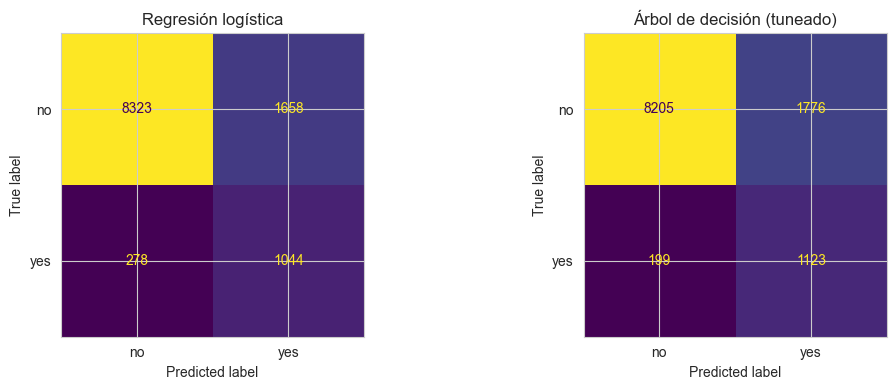

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay.from_estimator(lr_clf, X_test_scaled, y_test, ax=axes[0], colorbar=False)
axes[0].set_title("Regresión logística")

ConfusionMatrixDisplay.from_estimator(mejor_arbol, X_test, y_test, ax=axes[1], colorbar=False)
axes[1].set_title("Árbol de decisión (tuneado)")

plt.tight_layout()
plt.show()


Las métricas de train y test del árbol tuneado son mucho más parecidas que las del árbol
sin tunear, así que la optimización ha corregido en gran medida el sobreajuste inicial, y el
modelo generaliza razonablemente bien. Comparando las matrices de confusión, el árbol
detecta más "yes" reales (mayor recall de la clase positiva) que la regresión logística,
a costa de algunos falsos positivos adicionales -- un balance razonable para una campaña de
marketing donde contactar de más es mucho más barato que perder un cliente potencial.

In [38]:
importancias = pd.DataFrame({
    "feature": mejor_arbol.feature_names_in_,
    "importancia": mejor_arbol.feature_importances_,
}).sort_values("importancia", ascending=False)

importancias.head(15)


,feature,importancia
33,duration,0.419728
24,month,0.133837
27,poutcome_success,0.121757
32,day,0.085374
2,contact_unknown,0.077178
7,housing,0.043957
31,balance,0.033633
30,age,0.028042
35,pdays,0.012488
20,loan,0.007763


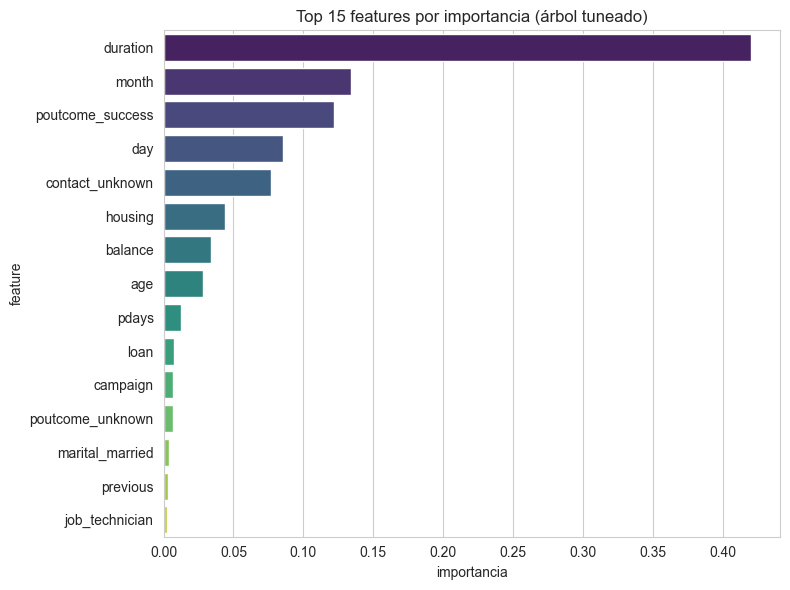

In [39]:
plt.figure(figsize=(8, 6))
sns.barplot(data=importancias.head(15), x="importancia", y="feature", hue="feature",
            palette="viridis", legend=False)
plt.title("Top 15 features por importancia (árbol tuneado)")
plt.tight_layout()
plt.show()


`duration` (duración de la última llamada) domina claramente la importancia, seguida de
variables relacionadas con el mes de contacto, si ya se había contactado antes, y el saldo.
Esto es coherente con la intuición de negocio: cuanto más tiempo dura la conversación, más
interesado suele estar el cliente.

### EXTRA: ¿nos vale con menos features?

Probamos a reentrenar ambos modelos usando solo las **8 features más importantes** según el
árbol, para ver si podemos simplificar el modelo sin perder apenas rendimiento.

> Nota: seleccionar features mirando la importancia del árbol entrenado sobre train y luego
> reevaluar sobre test introduce un ligero sesgo optimista. Para un proceso totalmente
> riguroso, este paso debería integrarse dentro de la validación cruzada. Aquí lo hacemos
> como comprobación exploratoria.

In [40]:
NUM_FEATURES = 8
top_features = importancias.head(NUM_FEATURES)["feature"].to_list()
top_features


['duration',
 'month',
 'poutcome_success',
 'day',
 'contact_unknown',
 'housing',
 'balance',
 'age']

In [41]:
X_train_top = train_set[top_features].copy()
X_train_scaled_top = train_set_scaled[top_features].copy()
X_test_top = test_set[top_features].copy()
X_test_scaled_top = test_set_scaled[top_features].copy()

lr_top = LogisticRegression(max_iter=1000, class_weight="balanced")
lr_top.fit(X_train_scaled_top, y_train)

print("--- LR con top features (test) ---")
print(classification_report(y_test, lr_top.predict(X_test_scaled_top)))


--- LR con top features (test) ---
              precision    recall  f1-score   support

          no       0.96      0.84      0.90      9981
         yes       0.38      0.76      0.51      1322

    accuracy                           0.83     11303
   macro avg       0.67      0.80      0.70     11303
weighted avg       0.90      0.83      0.85     11303



In [42]:
tree_grid_top = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring=f1_yes,
    n_jobs=-1,
)
tree_grid_top.fit(X_train_top, y_train)

print(tree_grid_top.best_params_)
print(f"F1(yes) CV: {tree_grid_top.best_score_:.4f}")

print("\n--- Árbol con top features (test) ---")
print(classification_report(y_test, tree_grid_top.best_estimator_.predict(X_test_top)))


{'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}
F1(yes) CV: 0.5338

--- Árbol con top features (test) ---
              precision    recall  f1-score   support

          no       0.97      0.82      0.89      9981
         yes       0.37      0.80      0.51      1322

    accuracy                           0.82     11303
   macro avg       0.67      0.81      0.70     11303
weighted avg       0.90      0.82      0.84     11303



Con solo 8 features (de las más de 30 que teníamos tras el one-hot encoding), el
rendimiento en test se mantiene muy cercano al del modelo completo. Es una señal de que
muchas de las variables categóricas codificadas aportan poco de forma individual, y un
modelo más simple e interpretable es casi igual de bueno.

### Conclusiones

- El target está muy desbalanceado (~88%/12%), así que hemos priorizado **F1 de la clase
  "yes"** sobre la accuracy en todo el proceso de evaluación y optimización.
- Un árbol sin restricciones sobreajusta claramente (F1 ~1.0 en train, mucho más bajo en
  test); la búsqueda de hiperparámetros (`max_depth`, `min_samples_leaf`, `criterion`,
  `class_weight`) corrige en gran medida ese sobreajuste.
- El **árbol de decisión optimizado supera a la regresión logística baseline** en F1 de la
  clase positiva, evaluados ambos de forma justa por validación cruzada.
- `duration`, el mes de contacto y si el cliente ya había sido contactado antes son las
  variables más determinantes.
- Reducir a las 8 features más importantes mantiene un rendimiento muy similar, lo que
  sugiere que un modelo bastante más simple sería suficiente en producción.
- **Me quedaría con el árbol de decisión tuneado**: rinde mejor que la regresión logística
  en la métrica que de verdad importa para el negocio (detectar clientes que van a
  contratar) y, además, es más interpretable gracias al feature importance.